# Natural-speech TRF on a real cohort

An end-to-end walkthrough of TRFlearn on **17 participants** listening to an audiobook,
from the preprocessed recordings to threshold-free cluster-corrected group inference.

This is the repository's one example built on a **public, real EEG dataset** rather than
a simulation, and it is organised in two parts:

- **Part I — the envelope TRF.** A single predictor, fitted the way the library is meant
  to be used, producing the classic auditory response. Everything the library offers
  around a fit — metric choice, design diagnostics, the whole plotting API, cohort
  statistics, bootstrap, TFCE — is exercised here.
- **Part II — adding acoustic onsets.** A second, correlated predictor enters the *same*
  model. This is where joint estimation, between-block collinearity and formal model
  comparison become meaningful — and where the tidy envelope kernel stops being tidy,
  for reasons worth understanding.

| | |
|---|---|
| **Data** | Natural Speech (Di Liberto et al. 2015; Broderick et al. 2018), 17 subjects × 20 runs |
| **Recording** | BioSemi 128-channel ActiveTwo, 128 Hz, mastoid-referenced, ICA-cleaned |
| **Predictors** | acoustic **envelope**, plus **onsets** in Part II |
| **Window** | −150 to 450 ms, fitted with a 50 ms margin that is trimmed afterwards |
| **Fit** | `cv="pooled"`, 5 block-stratified folds, ridge, λ searched per subject |
| **Inference** | TFCE, 1024 permutations, full channel × delay adjacency |

## 1 · The data

**The task.** Healthy adult participants listened to a professionally recorded audiobook
of Hemingway's *The Old Man and the Sea*, presented as **20 continuous runs** of roughly
three minutes each — about an hour of speech per person. There is no trial structure and
nothing to respond to: subjects simply listened to uninterrupted natural narration while
128-channel EEG was recorded with a BioSemi ActiveTwo system at 512 Hz. That continuity
is the point. Because the stimulus never stops, responses to successive acoustic events
overlap continuously, and averaging cannot separate them — which is precisely the
situation a temporal response function exists to handle. 

The recordings come from Di Liberto, O'Sullivan & Lalor (2015) and were extended by
Broderick et al. (2018).

**Two public releases, and why both are needed.** The same experiment was published
twice, and neither release is self-sufficient:

| Field | OpenNeuro (`ds004408`) | Dryad (`10.5061/dryad.070jc`) |
|---|---|---|
| State | raw, unfiltered, unreferenced, 512 Hz | the same signal at 128 Hz, still unreferenced |
| Format | BIDS / BrainVision, 128 scalp channels | MATLAB `.mat`: `eegData`, `mastoids`, `fs` |
| **Mastoid channels** | **absent** | **present** — the only way to re-reference |
| **Bad-channel flags** | **present** (`*_channels.tsv`) | **absent** |
| Stimuli | `.wav` + forced-aligned `.TextGrid` | precomputed 128 Hz envelopes |

[OpenNeuro](https://openneuro.org/datasets/ds004408) records which electrodes were bad; only [Dryad](https://datadryad.org/dataset/doi:10.5061/dryad.070jc) carries the mastoids the original analysis referenced to. Reproducing the published pipeline needs both — which first requires knowing which OpenNeuro subject is which Dryad subject, since the two releases number their participants differently and neither provides a key.

**Recovering the correspondence.** Correlating subjects directly does not work: everyone
heard the same audiobook, so every pair shares the same stimulus-driven response and
correlates at r ≈ 0.6 whether matched or not. The mapping was instead established by
resampling OpenNeuro to 128 Hz, searching the lag between the two recordings of each run
(OpenNeuro keeps a variable pre-roll of up to ~12 s; Dryad is trimmed to the audio), and
requiring the same partner to win in **every one of the 20 runs**. At the correct lag a
true pair reaches r ≈ 0.92–1.00 and wins consistently, while a subject with no
counterpart changes partner run to run and never exceeds ~0.82. **18 of 19 subjects map
one-to-one**; OpenNeuro `sub-003` and Dryad `Subject5` have no partner and are dropped.
A third, `sub11`, was excluded on inspection of its recordings. That is why this cohort
has 17 members and no `sub03` or `sub11`, and why subject numbering follows
**OpenNeuro's**.

**Preprocessing already applied to the files read below.**

1. **Re-referenced** to the average of the two mastoids, and cropped to the length of the
   corresponding stimulus envelope.
2. **Montage** `biosemi128`; channels flagged bad in OpenNeuro's `channels.tsv` are
   interpolated with spherical splines, so `info['bads']` is empty in the saved files.
3. **ICA**: extended Infomax, 20 components, fitted on the concatenated runs band-passed
   1–40 Hz *for the fit only*. Artefact components were selected by hand from topography
   and spectrum.
4. **Applied per run.** `ica.apply` is a fixed spatial projection, so the saved `.fif`
   files remain **broadband** — no temporal filter has touched them.

The band-pass is therefore left to the analysis, and this notebook applies it explicitly:
a **linear-phase FIR**, applied with its delay compensated so it is **zero-phase**. It is
MNE's windowed design (`firwin`, Hamming window, 845 taps, 6.6 s) with a passband of
1.5–14 Hz and transitions of 0.5 and 1 Hz: −6 dB at 1.25 and 14.5 Hz, and more than
50 dB down from 1 Hz and from 15 Hz on. Those are the edges of the original study's
filter, a Chebyshev type II IIR (order 4, 20 dB stopband) run forward and backward,
whose nominal "1–15 Hz" are where its stopband begins: a FIR asked for 1–15 Hz would
instead pass both edges whole, and with them the slow drifts below 1.5 Hz. A causal
filter would shift every peak and corrupt exactly the latencies of interest; the FIR's
phase is linear by construction rather than cancelled by a second pass, and its
stopband is deeper.
Like any zero-phase filter it is non-causal: it spreads every deflection to both sides in
time, so a response can leak into the negative delays of a kernel.

**The predictor.** The acoustic envelope is the magnitude of the Hilbert analytic signal
of the waveform, resampled to the EEG's 128 Hz — a single continuous channel tracking how
the speech's amplitude rises and falls. Part II adds its half-wave-rectified derivative
as a second predictor, marking the sharp acoustic edges the envelope itself smooths over.

**Getting the data.** The preprocessed set is ~4 GB and lives outside this repository;
the two source releases are ~22 GB together. Download them from the links above and apply
the four steps described in the previous section, or point `DATA_ROOT` below at an
existing copy.

Those four steps are stated there in full — the mastoid reference, the `biosemi128`
montage with spherical-spline interpolation of the channels OpenNeuro flags as bad, the
20-component extended-infomax ICA fitted on the concatenated runs, and its per-run
application that leaves the saved files broadband. Everything the analysis below depends
on is in that description; nothing is deferred to a script you would have to read.

One step is **not automatable, and that is the point**: the ICA components to remove were
chosen by visual inspection of topography and spectrum. No threshold reproduces that
judgement, so anyone repeating this is adopting a set of hand-made decisions rather than
re-running a pipeline. That is exactly what separates an *example* from a *tutorial*, and
why this notebook lives in `examples/` — see [`tutorials/`](../../tutorials/) for material
that runs end to end with no downloads and no human in the loop.

### References

**Data**

- Di Liberto, G. M., O'Sullivan, J. A., & Lalor, E. C. (2015). Low-frequency cortical
  entrainment to speech reflects phoneme-level processing. *Current Biology*, 25(19),
  2457–2465.
- Broderick, M. P., Anderson, A. J., Di Liberto, G. M., Crosse, M. J., & Lalor, E. C.
  (2018). Electrophysiological correlates of semantic dissimilarity reflect the
  comprehension of natural, narrative speech. *Current Biology*, 28(5), 803–809.
- OpenNeuro dataset `ds004408`, version 1.0.8 — `doi:10.18112/openneuro.ds004408.v1.0.8`
- Dryad dataset — `doi:10.5061/dryad.070jc`

**Methods referenced above**

- Crosse, M. J., Di Liberto, G. M., Bednar, A., & Lalor, E. C. (2016). The Multivariate
  Temporal Response Function (mTRF) Toolbox: a MATLAB toolbox for relating neural signals
  to continuous stimuli. *Frontiers in Human Neuroscience*, 10, 604. — the reference
  implementation this library is measured against.
- Gorman, K., Howell, J., & Wagner, M. (2011). Prosodylab-Aligner: a tool for forced
  alignment of laboratory speech. *Canadian Acoustics*, 39(3), 192–193. — produced the
  `.TextGrid` phoneme alignments shipped with the OpenNeuro release.
- Fox, J., & Monette, G. (1992). Generalized collinearity diagnostics. *Journal of the
  American Statistical Association*, 87(417), 178–183. — the GVIF reported in section 12.
- Smith, S. M., & Nichols, T. E. (2009). Threshold-free cluster enhancement. *NeuroImage*,
  44(1), 83–98. — the correction used in section 11.

## 2 · Setup

The only hard requirement beyond TRFlearn is MNE, which does the file I/O, the filtering
and the sensor geometry.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import numpy as np
import re
import torch

import mne
mne.set_log_level("ERROR")

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="mne")

from trflearn import PooledTRF, TRFData, TRFGroup, TRFModel
from trflearn.verbosity import set_verbosity
set_verbosity("warning")

print(
    f"TRFlearn on {'GPU' if torch.cuda.is_available() else 'CPU'} "
      f"| torch {torch.__version__} | mne {mne.__version__}"
)

TRFlearn on GPU | torch 2.11.0+cu128 | mne 1.12.1


In [2]:
# ── Analysis configuration ───────────────────────────────────────────────────
FS           = 128                       # Hz, the rate the dataset ships at
WINDOW       = (-0.15, 0.45)             # TRF delay window, seconds
DELAY_MARGIN = 0.05                      # fitted wider, then trimmed (section 5)
GRID       = np.logspace(-8, 6, 36)    # ridge grid; the floor is deliberately low
METRIC_LIMIT  = 0.05                      # the "within 5 %" rule demonstrated in section 5
N_FOLDS      = 5
N_PERMUTATIONS = 1024                    # for TFCE
N_RESAMPLES  = 2000                      # for the bootstrap
SEED         = 42

# Linear-phase FIR (firwin, Hamming window), its delay compensated: zero phase.
# Passband 1.5-14 Hz with 0.5 and 1 Hz transitions, so it is attenuated from 1 Hz
# and from 15 Hz on: the edges of the original study's Chebyshev filter.
BAND    = (1.5, 14.0)
FIR     = dict(method="fir", phase="zero", fir_design="firwin",
               fir_window="hamming", l_trans_bandwidth=0.5,
               h_trans_bandwidth=1.0)

USE_GPU = torch.cuda.is_available()

DATA_ROOT = Path.cwd().parent.parent / "LalorData" / "NaturalSpeechReferencedDryad"
SUBJECTS  = sorted(int(m.group(1))
                   for p in (DATA_ROOT / "eeg_ica").glob("sub*")
                   if p.is_dir() and (m := re.fullmatch(r"sub(\d+)", p.name)))
SEGMENTS  = list(range(1, 21))
print(f"Subjects  : {len(SUBJECTS)} -> {SUBJECTS}")
print(f"Segments  : {len(SEGMENTS)} per subject")

Subjects  : 17 -> [1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19]
Segments  : 20 per subject


## 3 · Loading — and why the targets are `mne.Raw` objects

`TRFData` accepts its targets as plain arrays **or** as `mne.Raw`, one per segment. The
`Raw` route is preferable here and not merely for convenience: channel names, channel
types and the **montage** travel with the data into `TRFData.info`.

That matters more than it looks. Without a montage, `TRFGroup.tfce` has no channel
adjacency to build and **falls back to treating the 128 electrodes as independent** —
which would quietly invalidate the group statistics later on. Since these `.fif` files
already carry `biosemi128` embedded, passing `Raw` gets it right with no montage
bookkeeping at all, and every `Evoked`-based plot works immediately.

Note that **both** predictors are built here, including the one Part I will not use.

In [3]:
def load_aligned_segment(subject: int, segment: int):
    """One run: band-passed EEG as `mne.Raw`, plus the two stimulus predictors."""
    raw = mne.io.read_raw_fif(
        DATA_ROOT / "eeg_ica" / f"sub{subject:02d}" / f"eeg_segment{segment:02d}.fif",
        preload=True, verbose="error"
    )

    # Zero-phase FIR: no peak is shifted. A causal filter would delay every peak
    # and corrupt the latencies we care about.
    raw.filter(l_freq=BAND[0], h_freq=BAND[1], **FIR, verbose="error")

    env = np.load(DATA_ROOT / "stimuli" / "envelope" /
                  f"envelope_segment{segment:02d}.npy").astype(np.float64)

    # The envelope runs 7-11 samples longer than the EEG; trim both to the common
    # length so every design-matrix row means the same instant on both sides.
    n = min(len(env), raw.n_times)
    raw.crop(tmax=(n - 1) / FS, verbose="error")
    env = env[:n]

    # Acoustic onsets: half-wave-rectified derivative of the envelope. It keeps
    # the sharp rises the envelope smooths over. Used in Part II.
    onset = np.maximum(np.diff(env, prepend=env[0]), 0.0)

    return raw, env.reshape(-1, 1), onset.reshape(-1, 1)


def build_subject(subject: int, segments=SEGMENTS) -> TRFData:
    """A partitioned `TRFData` for one subject: 20 segments, both predictors."""
    raws, envelopes, onsets = [], [], []
    for seg in segments:
        r, e, o = load_aligned_segment(subject, seg)
        raws.append(r); envelopes.append(e); onsets.append(o)

    data = TRFData(
        features={"Envelope": envelopes, "Onset": onsets},
        y=raws,                      # montage + channel names ride along
        sample_rate=FS,
        use_gpu=USE_GPU
    )
    # Folds are a property of the data, not of the model.
    # Block-stratified so each fold draws from every segment instead of being one
    # contiguous chunk.
    return data.create_partitions(n_folds=N_FOLDS, stratify_by_segment=True)

### What one run looks like

EEG   22729 samples x 128 channels, montage: True
stim  Envelope (22729, 1), Onset (22729, 1)
corr(Envelope, Onset) = 0.354


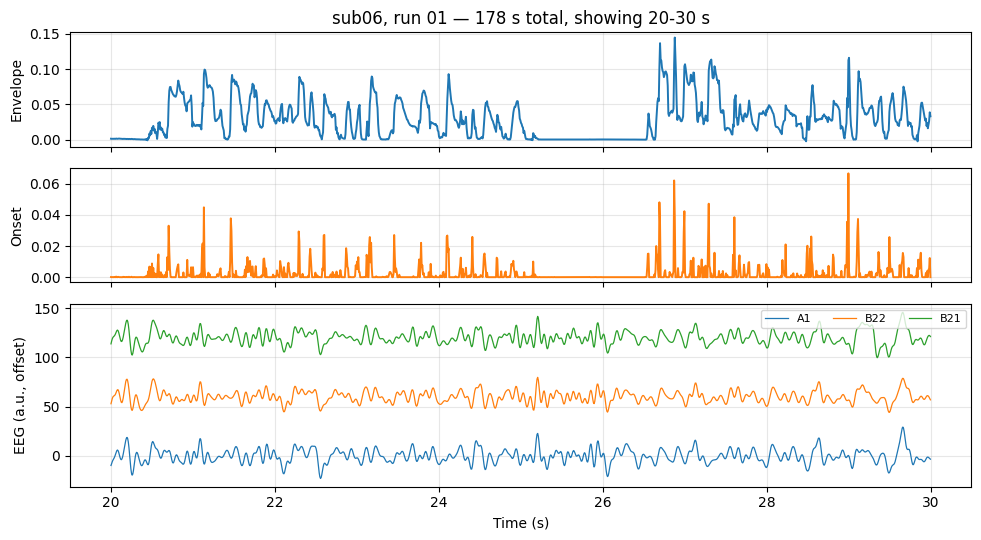

In [4]:
raw0, env0, onset0 = load_aligned_segment(SUBJECTS[4], 1)
t = np.arange(raw0.n_times) / FS
sl = slice(int(20 * FS), int(30 * FS))          # a 10-second window

fig, axes = plt.subplots(3, 1, figsize=(10, 5.5), sharex=True,
                         gridspec_kw=dict(height_ratios=[1, 1, 1.6]))
axes[0].plot(t[sl], env0[sl, 0], color="C0", lw=1.4)
axes[0].set_ylabel("Envelope")
axes[1].plot(t[sl], onset0[sl, 0], color="C1", lw=1.4)
axes[1].set_ylabel("Onset")
picks = ["A1", "B22", "B21"]
data_uv = raw0.get_data(picks=picks)[:, sl] * 1e6
for i, (ch, trace) in enumerate(zip(picks, data_uv)):
    axes[2].plot(t[sl], trace + i * 60, lw=.9, label=ch)
axes[2].set(xlabel="Time (s)", ylabel="EEG (a.u., offset)")
axes[2].legend(ncol=3, fontsize=8, loc="upper right")
for a in axes:
    a.grid(alpha=.3)
axes[0].set_title(f"sub{SUBJECTS[4]:02d}, run 01 — {raw0.n_times / FS:.0f} s total, "
                  f"showing 20-30 s")
plt.tight_layout()

print(f"EEG   {raw0.n_times} samples x {len(raw0.ch_names)} channels, "
      f"montage: {raw0.get_montage() is not None}")
print(f"stim  Envelope {env0.shape}, Onset {onset0.shape}")
print(f"corr(Envelope, Onset) = {np.corrcoef(env0[:, 0], onset0[:, 0])[0, 1]:.3f}")
del raw0

The two predictors are visibly related — the onset trace is, by construction, where the
envelope rises. That correlation is exactly what makes Part II interesting and Part I
clean, and it is quantified properly in section 12.

## 4 · The container holds candidates; the model chooses

`TRFData` is a container of **named candidate features**, not a fixed design. It holds
everything that might be modelled, and each model then names the subset it wants. That
separation is what the next two parts are built on: the container below carries
`Envelope` **and** `Onset`, Part I fits models that ask only for `Envelope`, and Part II
reuses the very same container to ask for both.

It is also deliberately **lazy**. Building it validates shapes and *records* the
partition configuration, but nothing is concatenated, no design matrix is assembled and
no fold is drawn. All of that depends on the delay window, which lives on the **model** —
so the container cannot know it yet. The first model to be constructed supplies it and
triggers `materialize`.

In [5]:
data = build_subject(SUBJECTS[2])
n_total = sum(data._seg_lengths)

print(f"targets   : {data.n_channels} channels -> {data.target_names[:4]} ...")
print(f"features  : {data.feature_order}, sub-feature dims {data.feature_dims}")
print(f"segments  : {len(data._seg_lengths)} runs, {n_total:,} samples "
      f"({n_total / FS / 60:.1f} min)")
print(f"montage   : {data.info.get_montage() is not None}  "
      f"(inherited from the .fif, never set by hand)")
print(f"device    : {data.device}")

# Laziness, made visible: the folds and the concatenated tensors do not exist
# yet, because their shape depends on a delay window the container has not been
# told about. A model supplies it and triggers `materialize`.
print(f"\nnot built yet -> folds: {data.folds} | y: {data.y} | "
      f"n_samples: {data.n_samples}")

targets   : 128 channels -> ['A1', 'A2', 'A3', 'A4'] ...
features  : ['Envelope', 'Onset'], sub-feature dims {'Envelope': 1, 'Onset': 1}
segments  : 20 runs, 464,572 samples (60.5 min)
montage   : True  (inherited from the .fif, never set by hand)
device    : cuda

not built yet -> folds: None | y: None | n_samples: None


---

# Part I — The envelope TRF

One predictor, `Envelope`, selected out of a container that holds two. Everything from
here to section 11 uses that single-feature model.

## 5 · One subject, and what the choices actually do

`cv="pooled"` is TRFlearn's default and the recommended one: for each held-out fold a
model is fitted on the pooled complement, so nothing in the reported score was seen while
fitting. `gridsearchCV` searches λ on an inner split of the training data and then
**refits at the winner** — the refit is not optional at the cohort level, so a reported
kernel is always one that was actually fitted.

Two settings deserve to be spelled out rather than left at their defaults.

**`delay_margin=0.05`.** Ridge regression rings at the edges of the delay window: the
first and last lags have no neighbours on one side, and the penalty pulls them toward
zero in a way that bends the kernel where it should simply end. Fitting 50 ms wider on
each side and then **trimming the margin off before predicting** moves that artefact
outside the window you actually look at. The kernel comes back at the requested
−150–450 ms; the fit that produced it was wider.

**The metric.** Pearson correlation is the convention in the TRF literature, but it is a
convention. Below, the same data and the same λ grid are searched under three different
metrics, plus one variant that deliberately prefers a smoother model. The parameters are
written out in full so the choices are legible, even where they match the defaults.

In [6]:
FEATURE = ["Envelope"]          # one name, out of the two the container holds

fits: dict[str, tuple[PooledTRF, float]] = {}
for name, metric, limit in [("Pearson",       "Pearson", None),
                            ("R²",            "R²",      None),
                            ("RMSE",          "RMSE",    None),
                            ("Pearson, 5 %",  "Pearson", METRIC_LIMIT)]:
    model = TRFModel(
        data, FEATURE, WINDOW,
        cv="pooled",                     # k-fold; the default paradigm
        solver="ridge",                  # the default
        feature_preprocess="Standardize",  # the default: z-scored with train stats
        target_preprocess="Standardize",   # idem
        delay_margin=DELAY_MARGIN,       # fit wider, trim after
    )
    regularization, _ = model.gridsearchCV(
        GRID,
        metric=metric,
        metric_aggregation_function="mean",   # how folds are pooled; the default
        metric_limit_percentage=limit,        # None = simply take the best λ
        inner_train_cutoff=0.8,               # the default inner split
        validation_plot=False,
    )
    fits[name] = (model, regularization)

print(f"{'selection rule':16s} {'λ':>12s} {'score (mean)':>14s} {'best channel':>14s}")
for name, (model, regularization) in fits.items():
    v = model.metric_.cpu().numpy().ravel()
    best = v.min() if model.metric_name_ == "RMSE" else v.max()
    print(f"{name:16s} {regularization:>12.4g} {v.mean():>14.4f} {best:>14.4f}")

selection rule          alpha   score (mean)   best channel
Pearson                0.1585         0.0650         0.0901
R²                     0.1585         0.0046         0.0081
RMSE                   0.1585         0.9982         0.9962
Pearson, 5 %             6.31         0.0615         0.0857


Those four rows are worth reading slowly, because they explain a convention.

**Why Pearson is the standard**: the main reason is that this metric is scale-invariant,
so a response can be real, correctly timed, and still amount to a few percent of
correlation without being penalised for its small amplitude. That is precisely why the
TRF literature reports correlation, and why this notebook does too.

The rest is bookkeeping worth knowing: **RMSE is the only registered metric where lower is
better**, so the search flips its sign internally to keep "best" meaning one thing; and
held-out R² **can be negative**, which is information rather than failure.

**Here the three metrics agree**, and the reason is in the curve below: the score is flat
from the bottom of the grid up to λ ≈ 0.1 and only then turns. With one predictor, 90
design columns and nearly half a million samples, the normal equations are well
conditioned and the penalty has almost nothing to do until it grows large enough to start
smoothing the kernel. Whatever the metric, it peaks where that plateau ends.

**And then there is the fourth row, which is not a curiosity.** Compare it against the
first: `metric_limit_percentage=0.05` asks a different question — not "which λ scores
highest?" but "which is the **largest** λ still within 5 % of the best?" — and it lands
some forty times further along the grid (6.31 against 0.16) for a held-out r a few
thousandths lower. That is the plateau's shoulder: the most regularisation the data
tolerate before it costs anything that matters.

On a plateau a plain `argmax` is choosing between near-ties, and for a subject whose curve
never turns it settles on the bottom of the grid. That is worth *knowing* — it says the
penalty is not what is limiting that fit — but it is not by itself a problem, and it is
why section 9 checks the two grid endpoints separately rather than treating both as
warnings.

The cohort below keeps the plain Pearson rule. The 5 % variant is a real option and
sometimes the right one, particularly with fewer data per subject or a visibly noisy
kernel; here the two score nearly the same (0.0650 against 0.0615), so the notebook stays
with the convention and shows the alternative rather than quietly imposing it.


**`validation_plot`** — the λ search made visible, and the reason to look at all four.
The left panel is the held-out metric against λ with the selection marked; the panel
beside it stacks the kernel at every λ on the grid. Read together, the curve says *which*
λ won and the stack says *what regularisation was doing to the shape* on the way there.

This is where the paragraph above becomes something you can see rather than take on
trust: all three curves have the same shape — flat over the bottom of the grid, a barely
visible optimum where the plateau ends, and a fall beyond it (a rise, for RMSE) as the
penalty starts to shrink the kernel. The stack shows what that fall costs: the peaks
lower and widen as λ grows. A metric curve that never turned around, climbing toward the
largest λ on offer, would be the signature of a selection rule that wants no model at
all; none of these does.


── Pearson ────────────────────────────────────────────────────────────


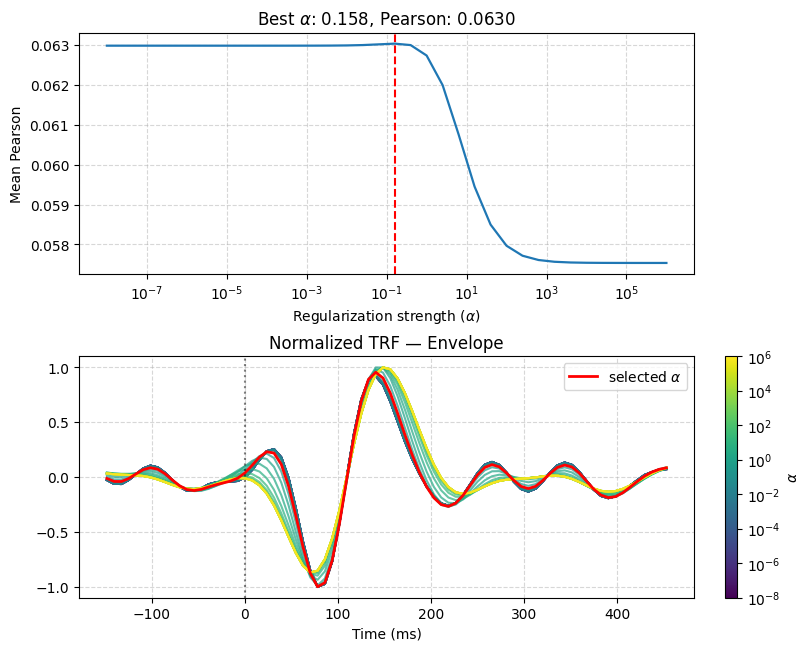

── R² ────────────────────────────────────────────────────────────


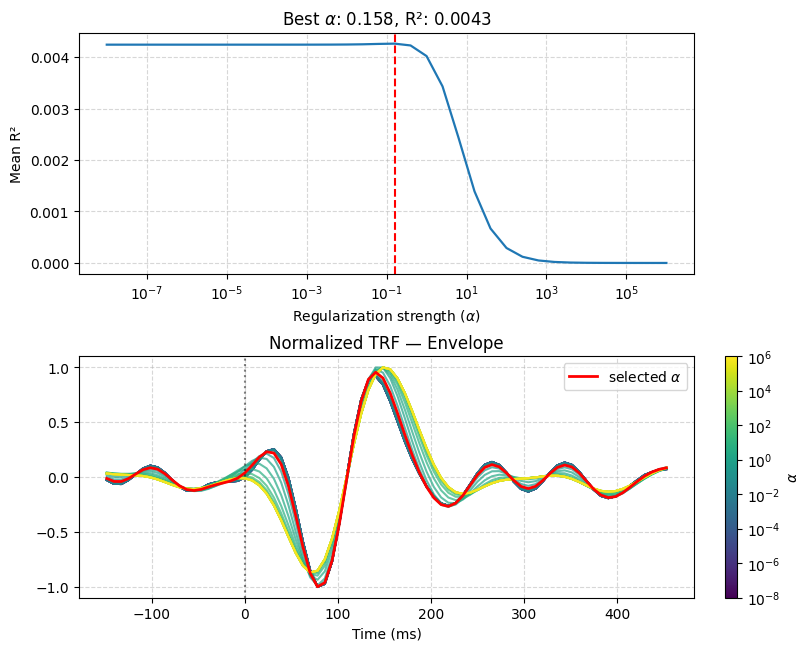

── RMSE ────────────────────────────────────────────────────────────


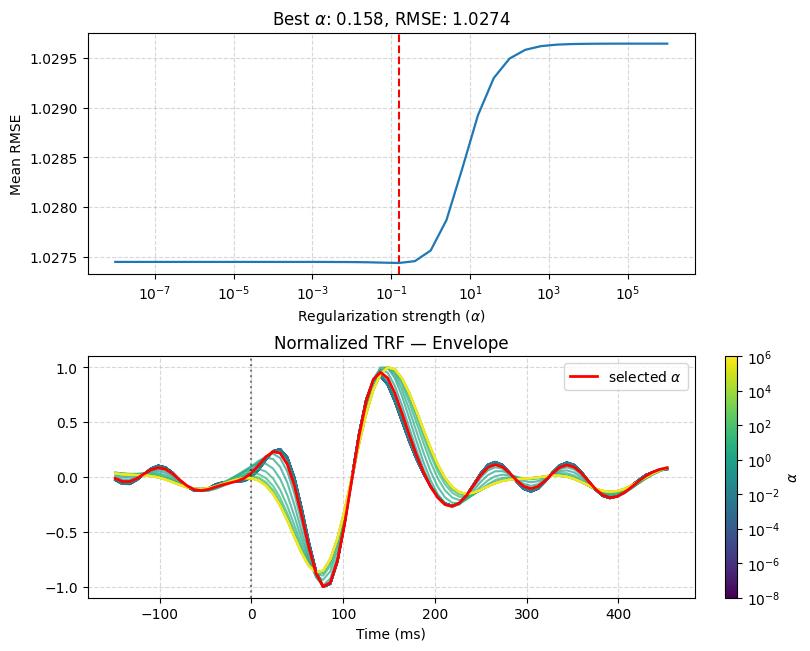

── Pearson, 5 % ────────────────────────────────────────────────────────────


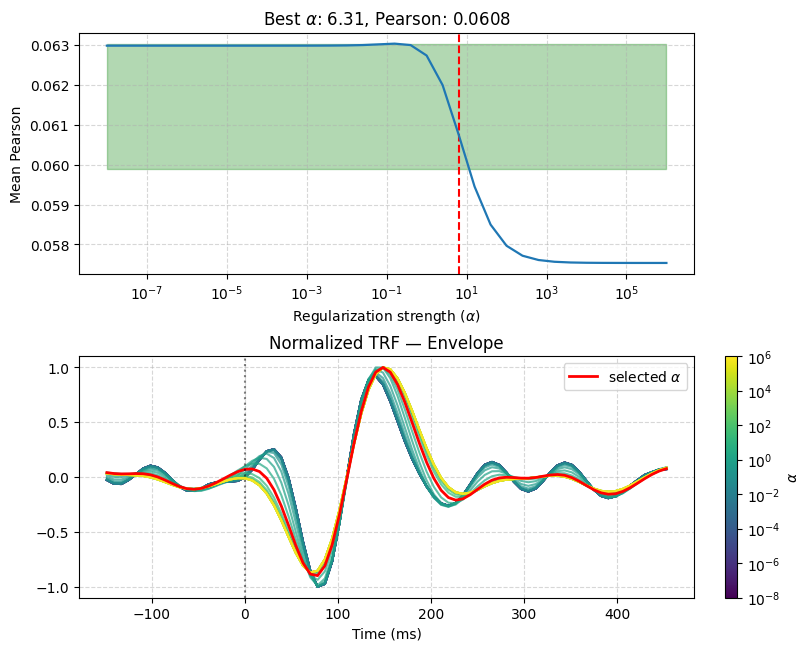

In [7]:
for name, (model, _) in fits.items():
    print(f"── {name} " + "─" * 60)
    model.validation_plot(show=True)

**`plot_metric_topomap`** — the same four models, scored on the scalp. The three metrics
chose the same λ, so the first three maps score *one* model three ways. Pearson and R²
should show structure, and structure in the right place: fronto-central, where an
auditory response belongs. Held-out correlations of a few hundredths per channel are
normal for single-trial continuous speech.

RMSE is the control, and it should look **empty**: in standardised units it sits a hair
below 1 on every channel, a flat field on a scale that includes zero. A model that
explains a few thousandths of the variance barely moves an error measured against the
signal's whole spread — so the same fit that Pearson reads as a clear topography is
invisible to RMSE. That is the clearest possible statement that the selection metric is a
modelling decision, not a formatting one.


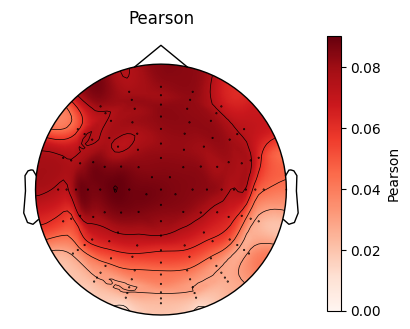

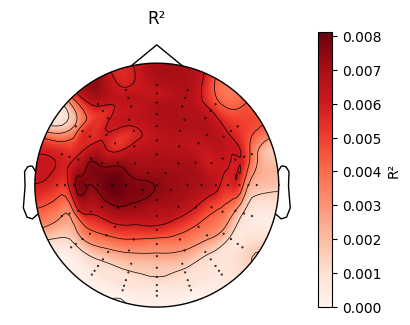

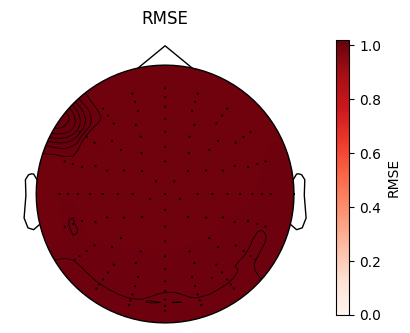

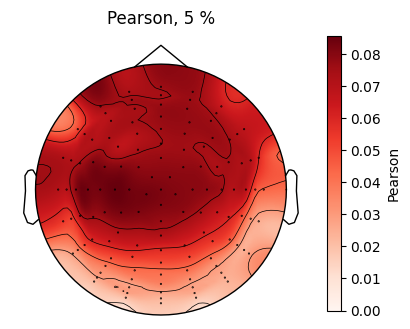

In [8]:
for name, (model, _) in fits.items():
    model.plot_metric_topomap(title=f"{name}", show=True)

The plain Pearson model is the one carried forward.

In [9]:
model, best_regularization = fits["Pearson"]
model.fit(regularization=best_regularization, metric="Pearson") 

print(f"carrying forward: λ = {best_regularization:.4g}, "
      f"mean held-out r = {model.metric_.cpu().numpy().mean():.4f}")
print(f"  (the 5 % rule would pick λ = {fits['Pearson, 5 %'][1]:.4g} "
      f"whose score is within 5 % of the best)")

carrying forward: alpha = 0.1585, mean held-out r = 0.0650
  (the 5 % rule would pick alpha = 6.31 whose score is within 5 % of the best)


## 6 · Diagnosing the design

Before trusting a kernel, ask whether the design that produced it was well posed.
**`model.diagnostics()`** answers that. It is computed on demand rather than during
fitting — it costs a full extra pass over the design — and it needs the fitted λ, because
the condition number it reports is that of the *regularised* normal matrix, which is the
matrix actually inverted.

| quantity | what it says |
|---|---|
| `condition_number` | how close the regularised system is to singular; > 1e6 warns |
| `effective_rank` | participation ratio of the *unregularised* design — how many directions genuinely carry variance |
| `vif` | generalised VIF **per feature block** (Fox & Monette), so collinearity *within* the lag axis is not counted as a problem |
| `vif_columns` / `vif_aliased` | per design column; `inf` marks exact linear dependence |

In [10]:
diag = model.diagnostics(vif=True, criteria=True)

print(f"condition number : {diag['condition_number']:.3e}")
print(f"effective rank   : {diag['effective_rank']:.1f} "
      f"of {np.size(diag['vif_columns'])} design columns")
print(f"aliased columns  : {np.size(diag['vif_aliased'])}")
print(f"GVIF             : {np.atleast_1d(diag['vif'])}   <- one block, nothing to share with")

condition number : 1.677e+02
effective rank   : 6.9 of 90 design columns
aliased columns  : 0
GVIF             : [nan]   <- one block, nothing to share with


Two of the three say something here, and the third says nothing *by construction*.

**The effective rank is far below the column count.** About seven effective directions
out of 90 design columns is not a defect — it is what a lagged low-frequency
predictor *is*. Neighbouring delays of a slowly varying signal are nearly the same
regressor, so the design's variance concentrates into a handful of directions. This is
precisely why ridge is not optional: the unregularised problem is close to singular, and
the penalty is what makes it solvable.

**The condition number is of the regularised matrix** — the one actually inverted. It
reflects the problem after λ has done its work, which is why the diagnostic needs a
fitted λ and refuses to run before one exists.

**The GVIF is empty, and has to be.** It measures how much a feature block duplicates
*the other blocks*, and a single-block design has no other blocks. This is not a
limitation to work around; it is the diagnostic correctly reporting that the question
does not apply yet. In Part II it will.

## 7 · The plotting API on a single subject

Every figure below is a method on the fitted object, returns its `Figure`, and accepts
`save_path`. Models, cohorts and individual subjects share one API, so nothing here has
to be relearned at the group level.

Kernel amplitudes are in **coefficient units** (σ_EEG / σ_x under standardisation), never
µV — the model was fitted on standardised data, and labelling the axis in volts would be
a fiction.

**`plot`** — MNE's butterfly of the kernel, with a black channel-mean and a ±1 SD band
over the per-channel traces.

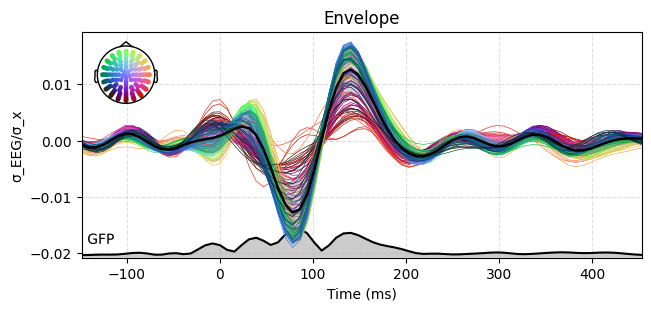

In [11]:
model.plot("Envelope", x_units="ms", gfp=True, show=True); 

**`plot_joint`** — the same butterfly with topographies at the peaks. This is the figure
that shows a TRF *is* a TRF: a low-frequency waveform with a plausible auditory
topography at each deflection.

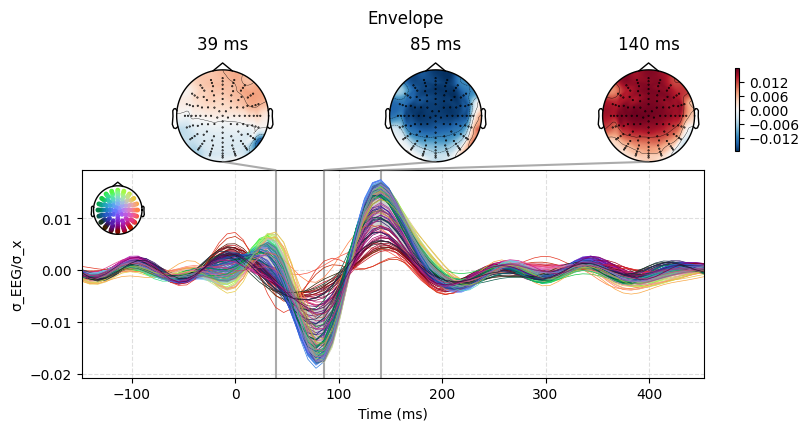

In [12]:
model.plot_joint("Envelope", x_units="ms", show=True, mean=False);

**`plot_image`** — channels × delays as a heatmap, for telling a global deflection from
one confined to a subset of sensors.

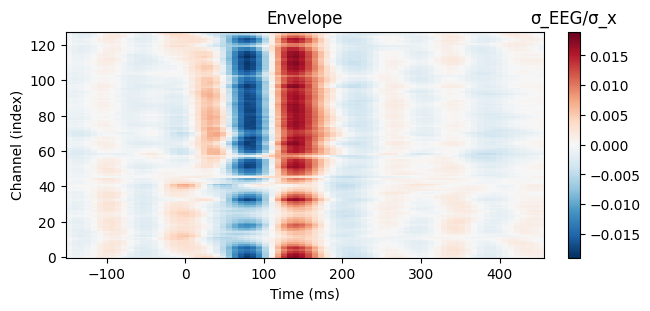

In [13]:
model.plot_image("Envelope", x_units="ms", show=True);

**`plot_average`** — the fallback that needs no sensor geometry. With a montage present
it still draws MNE's butterfly by default; `style="native"` opts out and renders the
figure the way it would look for data with no montage at all — which is what a cohort
recorded on an unknown or custom layout gets.

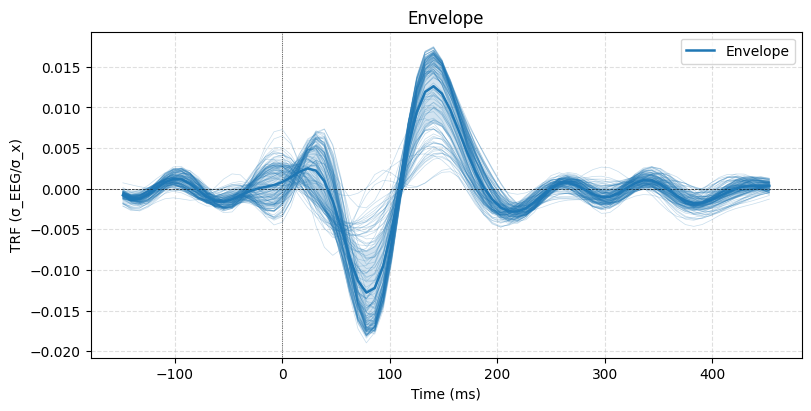

In [14]:
model.plot_average("Envelope", style="native", x_units="ms", show=True); 

**`plot_psd`** — the kernel's own spectrum. Worth one look and no more: the signal was
band-passed to 1.5–14 Hz before fitting, so the kernel *cannot* carry energy outside that
range and the plot is a confirmation that nothing went wrong upstream rather than a
finding. If power did appear above the passband, the filter would not be doing what
section 1 says it does.

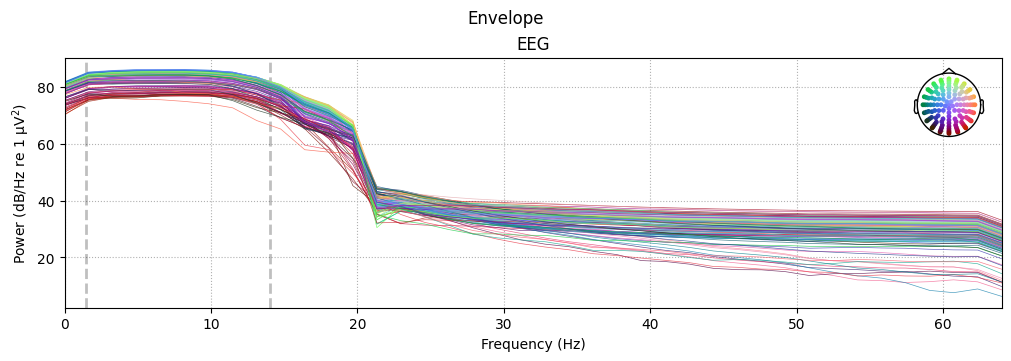

In [15]:
model.plot_psd("Envelope", show=True); 

## 8 · Fitting the cohort

`TRFGroup` declares the model spec **once, without data**, fits it per subject, keeps only
the minimal per-subject record — kernels, held-out metric, selected λ, diagnostics — and
discards each full model. That is what makes 17 subjects × 60 minutes tractable in a
notebook.

Two flags must be set **before** fitting and cannot be recovered afterwards, precisely
because each subject's model is discarded:

- `criteria=True` — records AIC/BIC, without which Part II's `compare_to` cannot run;
- `diagnostics=True` — records the design report from section 6 for every subject.

Note also what is *absent* from the loop: there is no `run_fit` argument. `fit_subject`
forces `run_fit=True` and rejects `run_fit=False` outright — a cohort whose members were
never refitted at their selected λ would have no kernels to average, so the API refuses
to build one.

In [16]:
envelope_group = TRFGroup(
    ["Envelope"], default_window=WINDOW,
    cv="pooled", solver="ridge",
    delay_margin=DELAY_MARGIN,
    regularization_grid=GRID, metric="Pearson",
    diagnostics=True, criteria=True,
    bootstrap=True, n_resamples=N_RESAMPLES, random_state=SEED,
)
print("spec:", envelope_group.features, "| window:", WINDOW, 
      "| margin:", DELAY_MARGIN, "s")

spec: ['Envelope'] | window: (-0.15, 0.45) | margin: 0.05 s


In [17]:
for sub in SUBJECTS:
    sid = f"sub{sub:02d}"
    subject_data = build_subject(sub)
    envelope_group.fit_subject(subject_data, sid)
    res = envelope_group.results(sid)
    r = np.asarray(res["metric"]).reshape(-1)
    print(f"  {sid}  λ {res['regularization']:<9.4g}  r mean {r.mean():.4f}  "
          f"max {r.max():.4f}  cond {res['condition_number']:.2e}")

    del subject_data

print(f"\nfitted {len(envelope_group)} subjects")

  sub01  alpha 1          r mean 0.0137  max 0.0248  cond 2.96e+01


  sub02  alpha 1e-08      r mean 0.0101  max 0.0192  cond 1.85e+03


  sub04  alpha 0.1585     r mean 0.0650  max 0.0901  cond 1.68e+02


  sub05  alpha 0.1585     r mean 0.0192  max 0.0291  cond 1.68e+02


  sub06  alpha 0.02512    r mean 0.0166  max 0.0270  cond 7.12e+02


...

  sub15  alpha 0.3981     r mean 0.0331  max 0.0530  cond 7.12e+01


  sub16  alpha 0.1585     r mean 0.0447  max 0.0700  cond 1.68e+02


  sub17  alpha 0.3981     r mean 0.0090  max 0.0130  cond 7.12e+01


  sub18  alpha 2.512      r mean 0.0448  max 0.0638  cond 1.25e+01


  sub19  alpha 0.02512    r mean 0.0293  max 0.0475  cond 7.12e+02

fitted 17 subjects


## 9 · Cohort descriptive statistics

**`summary()`** gives cohort size and the spread of the per-subject numbers;
**`grand_average()`** returns mean / SD / SEM of the kernels across subjects.

In [18]:
summ = envelope_group.summary()

print(f"cohort   : {summ['n_subjects']} subjects, specs {summ['specs']}")
print(f"channels : {len(envelope_group.common_channels)} shared across every subject")
print()

m = summ["metric"]
print(f"held-out Pearson r  grand mean {m['grand_mean']:.4f}  "
      f"| across subjects: min {m['min']:.4f}, median {m['median']:.4f}, "
      f"max {m['max']:.4f}")

a = summ["regularization"]
print(f"selected λ      median {a['median']:.4g}  "
      f"| range {a['min']:.4g} to {a['max']:.4g}")

ga = envelope_group.grand_average()
print()
for spec, d in ga.items():
    print(f"grand average {spec:9s}: mean {d['mean'].shape} "
          f"(channels, sub-features, delays), n = {d['n']}")

cohort   : 17 subjects, specs ['Envelope']
channels : 128 shared across every subject

held-out Pearson r  grand mean 0.0299  | across subjects: min 0.0090, median 0.0274, max 0.0650
selected alpha      median 0.3981  | range 1e-08 to 15.85

grand average Envelope : mean (128, 1, 78) (channels, sub-features, delays), n = 17


### Two per-subject views, and the cohort's landmarks

The figure below is descriptive housekeeping — how well the model predicts for each
person, and how much regularisation each one needed. What to look for: prediction
accuracy varying by a factor of a few across subjects is normal; **λ spanning many orders
of magnitude is also normal**, because it absorbs per-subject differences in noise level.

The two grid endpoints are checked separately, because they mean opposite things. Landing
on the **ceiling** is a genuine warning: the search wants more regularisation than the
grid offers, which is a model being shrunk toward nothing, and the resulting kernel would
be flat. Landing on the **floor** is the flat-curve situation from section 5 — the one
subject that does so here has a design well enough conditioned that ridge has little
left to do, which is a fact about an hour of single-predictor data rather than a fault
in the search.

The final block reads the classic auditory landmarks — **P1, N1, P2** — off the
channel-averaged group kernel. This is the notebook's real validation step: if those
latencies land near the values reported for this paradigm, then the whole chain —
filtering, alignment, folds, the λ search, the margin trimming — is behaving.

r across cohort : 0.0299 (best channel per subject: 0.0495)
alpha on the grid floor  : 1 of 17   (flat metric curve; the penalty is not the limiting factor — section 5)
alpha on the grid ceiling: 0 of 17

delays kept     : -148 to 453 ms (78 lags, margin already trimmed)
group TRF peaks : P1 -8 ms, N1 78 ms, P2 148 ms   [literature: ~25 / ~80 / ~140 ms]


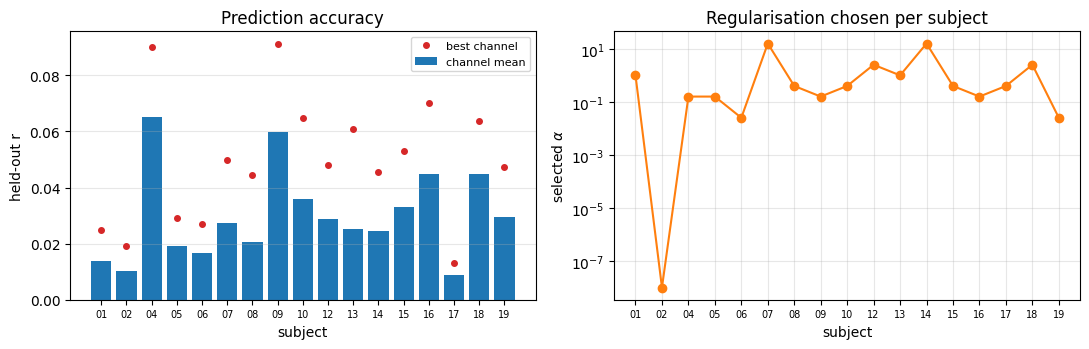

In [19]:
r_by_sub = np.stack([np.asarray(envelope_group.results(f"sub{s:02d}")["metric"]).reshape(-1)
                     for s in SUBJECTS])
values   = np.array([envelope_group.results(f"sub{s:02d}")["regularization"] for s in SUBJECTS])
x        = np.arange(len(SUBJECTS))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(x, r_by_sub.mean(1), color="C0", label="channel mean")
axes[0].plot(x, r_by_sub.max(1), "o", color="C3", ms=4, label="best channel")
axes[0].set_xticks(x, [f"{s:02d}" for s in SUBJECTS], fontsize=7)
axes[0].set(xlabel="subject", ylabel="held-out r", title="Prediction accuracy")
axes[0].legend(fontsize=8); axes[0].grid(alpha=.3, axis="y")

axes[1].semilogy(x, values, "o-", color="C1")
axes[1].set_xticks(x, [f"{s:02d}" for s in SUBJECTS], fontsize=7)
axes[1].set(xlabel="subject", ylabel=r"selected $\lambda$",
            title="Regularisation chosen per subject")
axes[1].grid(alpha=.3)
plt.tight_layout()

print(f"r across cohort : {r_by_sub.mean():.4f} "
      f"(best channel per subject: {r_by_sub.max(1).mean():.4f})")

on_floor   = (values <= GRID[0]).sum()
on_ceiling = (values >= GRID[-1]).sum()
print(f"λ on the grid floor  : {on_floor} of {len(SUBJECTS)}"
      + ("" if on_floor == 0 else
         "   (flat metric curve; the penalty is not the limiting factor — section 5)"))
print(f"λ on the grid ceiling: {on_ceiling} of {len(SUBJECTS)}"
      + ("" if on_ceiling == 0 else "   <-- the model is being shrunk away; widen GRID"))

delays = np.asarray(envelope_group.results(f"sub{SUBJECTS[0]:02d}")["delays"]["Envelope"])
t_ms   = delays / FS * 1e3
kernel = np.asarray(ga["Envelope"]["mean"])              # (channels, d, delays)
curve  = kernel.reshape(-1, kernel.shape[-1]).mean(axis=0)

early, late = (t_ms >= -50) & (t_ms <= 90), (t_ms >= 0) & (t_ms <= 300)
print(f"\ndelays kept     : {t_ms[0]:.0f} to {t_ms[-1]:.0f} ms "
      f"({len(t_ms)} lags, margin already trimmed)")
print(f"group TRF peaks : P1 {t_ms[early][curve[early].argmax()]:.0f} ms, "
      f"N1 {t_ms[late][curve[late].argmin()]:.0f} ms, "
      f"P2 {t_ms[late][curve[late].argmax()]:.0f} ms"
      f"   [literature: ~25 / ~80 / ~140 ms]")

**N1 and P2 land where the literature puts them; the P1 does not.** It peaks just before
zero rather than ~25 ms after it. A zero-phase filter spreads every deflection to both
sides in time (section 1), and the P1 — small, and right before the large N1 — is the
most exposed to that spread. The rest of the chain is behaving.


### Design diagnostics across the cohort

Section 6 diagnosed one subject, which cannot say much on its own. The question a cohort
asks is whether **this** subject's design is the odd one out, so
`summary()["diagnostics"]` reports the spread across subjects and names anyone carrying
an exact dependency. `aliased_subjects` should be empty; if it is not, those subjects
have redundant design columns and their kernels are not identified in those directions.

aliased subjects : none — every design is full rank
condition number : median 7.12e+01 | range 2.83e+00 to 1.85e+03


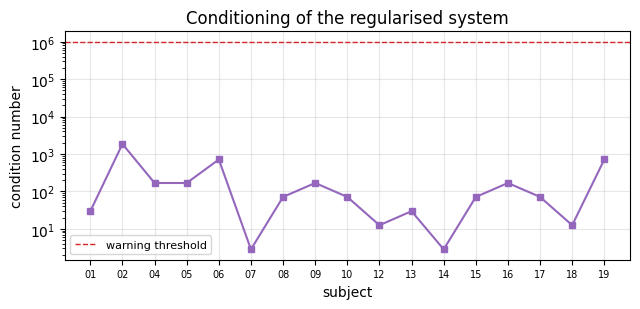

In [20]:
design = summ["diagnostics"]
cond   = np.array([design["condition_number"][f"sub{s:02d}"] for s in SUBJECTS])

print(f"aliased subjects : "
      f"{design['aliased_subjects'] or 'none — every design is full rank'}")
print(f"condition number : median {np.median(cond):.2e} | "
      f"range {cond.min():.2e} to {cond.max():.2e}")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.semilogy(x, cond, "s-", color="C4", ms=4)
ax.axhline(1e6, color="C3", ls="--", lw=1, label="warning threshold")
ax.set_xticks(x, [f"{s:02d}" for s in SUBJECTS], fontsize=7)
ax.set(xlabel="subject", ylabel="condition number",
       title="Conditioning of the regularised system")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout();

## 10 · Bootstrap distributions per subject

`bootstrap=True` resamples folds with replacement at fit time, giving each subject a
distribution for its held-out metric rather than a single number. **`plot_bootstrap`**
draws one violin per subject with the observed value, a percentile interval and the
cohort mean.

This is the figure that separates "the cohort average is positive" from "the cohort
average is positive **and** most individuals are individually credible" — a distinction
a bar chart of means cannot make.

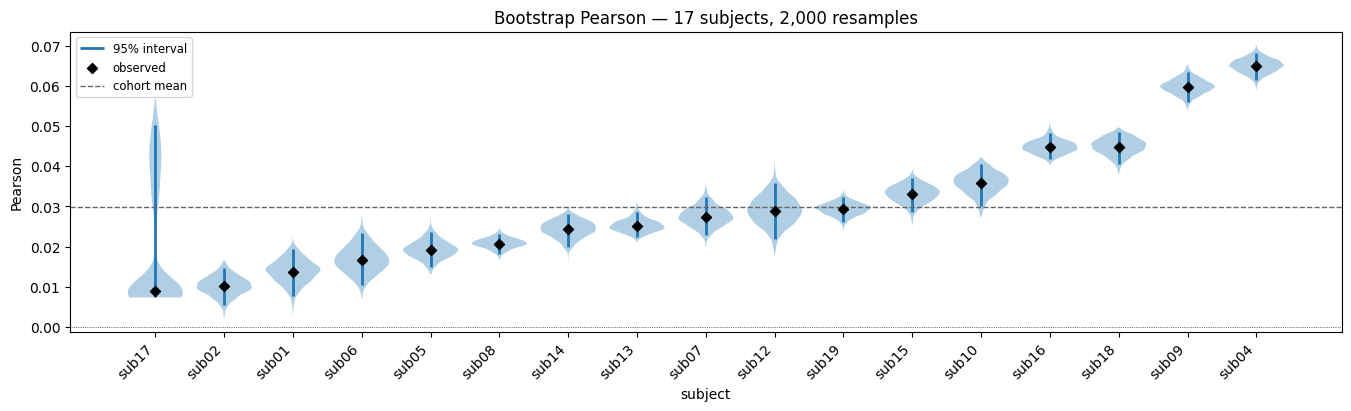

In [21]:
envelope_group.plot_bootstrap(kind="violin", ci=95, sort=True, show=True);

**`group(subject_id)`** returns a plotting view of one member, with the same API as the
cohort — useful for checking whether a subject at the bottom of that ranking is noisy or
simply different.

── sub04 ────────────────────────────────────────────────────────────


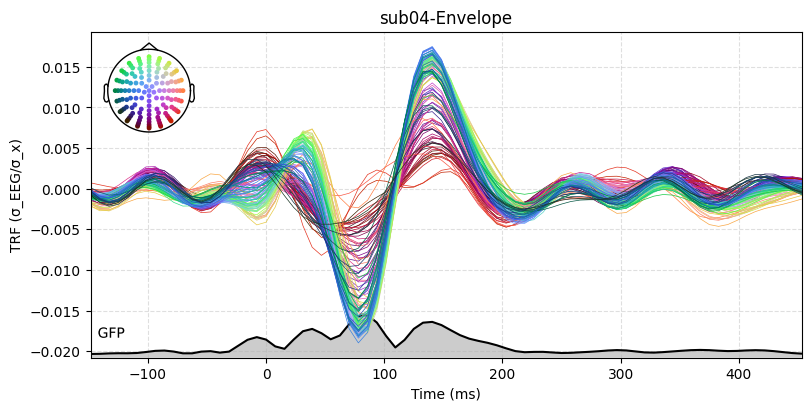

── sub17 ────────────────────────────────────────────────────────────


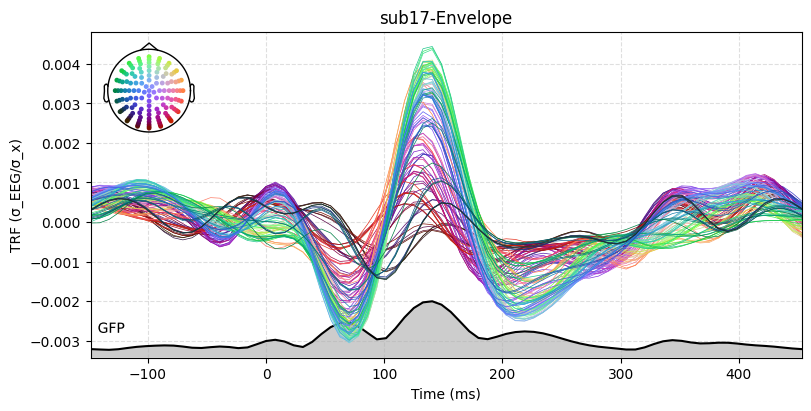

In [22]:
best  = f"sub{SUBJECTS[int(r_by_sub.mean(1).argmax())]:02d}"
worst = f"sub{SUBJECTS[int(r_by_sub.mean(1).argmin())]:02d}"

for sid in (best, worst):
    print(f"── {sid} " + "─" * 60)
    envelope_group(sid).plot_average("Envelope", x_units="ms", show=True)

## 11 · Group inference with TFCE

The question is whether the cohort's kernel departs from zero, controlling the family-wise
error over the **whole** delay × channel grid — 128 channels times the delay axis is a lot
of opportunities to find something.

**`group.tfce(spec)`** wraps `mne.stats.spatio_temporal_cluster_1samp_test` and builds the
full adjacency lattice (delays × channel neighbourhood) from the montage carried in
`TRFData.info`. This is where section 3's choice to pass `mne.Raw` pays off: without that
montage the channel adjacency degrades to the identity, every electrode becomes an island,
and the correction goes wrong **without raising anything**. The cell therefore captures
warnings and reports whether the adjacency fallback fired — an empty list is the check
that the correction used real sensor neighbourhoods.

**Why TFCE rather than cluster mass.** Under cluster mass the p-value belongs to the
*cluster*, not to any delay or channel inside it, so "this cluster is significant" is the
only honest statement and reading a latency off its edges is unsupported. TFCE returns a
genuine **per-point** p-value, which is what makes the shaded figures below interpretable.

What to expect: a fraction of the grid significant, concentrated around the N1 and the P2
over fronto-central sensors. Nothing significant, or everything significant, would both be
signs that something upstream is wrong.

In [23]:
t_obs, pvals = envelope_group.tfce("Envelope", n_permutations=N_PERMUTATIONS,
                                   seed=SEED, n_jobs=-1)
sig = pvals < 0.05
print(f"Envelope: t_obs {t_obs.shape} | {sig.sum():,} of {sig.size:,} points "
      f"p < .05 ({100 * sig.mean():.1f} %) | min p = {pvals.min():.4g}")

Envelope: t_obs (78, 128) | 1,843 of 9,984 points p < .05 (18.5 %) | min p = 0.0009766


### Significance-aware figures

Once the test has run its result is cached on the cohort, and the plotting API picks it up
automatically — the same calls from section 7 now shade what survived correction.

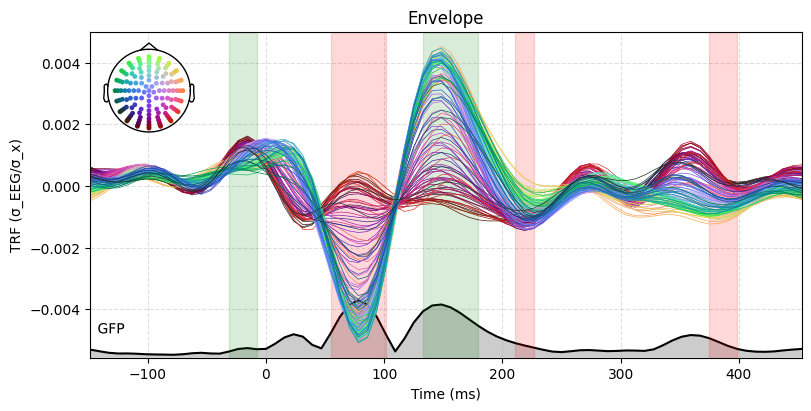

In [24]:
envelope_group.plot_average("Envelope", show_stats=True, min_sig_channels=0.3,
                            x_units="ms", show=True);

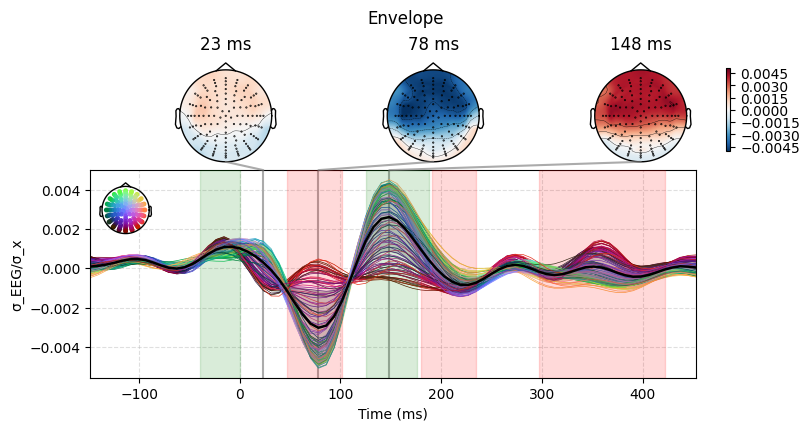

In [25]:
envelope_group.plot_joint("Envelope", show_stats=True, x_units="ms", show=True);

**`plot_features`** — the summary figure: the butterfly with significant spans shaded, the
channels × delays image with non-significant regions greyed out and a curve counting
significant channels at each delay, and a topography at the peak of the significant span.

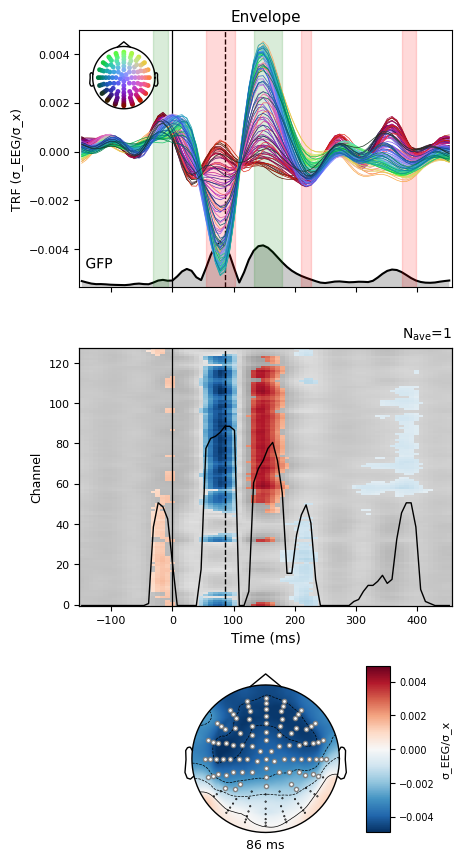

In [26]:
envelope_group.plot_features(show_stats=True, min_sig_channels=0.3, show=True);

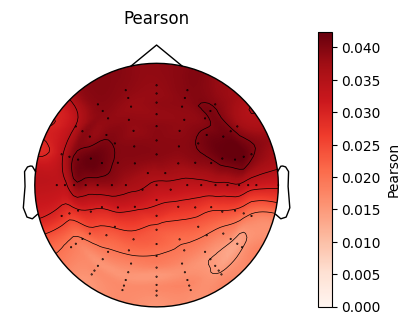

In [27]:
envelope_group.plot_metric_topomap(show=True);

---

# Part II — Adding acoustic onsets

The container has carried an `Onset` predictor since section 3 without any model asking
for it. Now one does.

The point of this part is not that two predictors are better than one. It is that adding a
**correlated** predictor changes what the first one means, and that TRFlearn gives you the
tools to see that happening rather than discover it later: a between-block collinearity
diagnostic that was empty in Part I, and a formal comparison that prices the extra
complexity instead of rewarding it automatically.

## 12 · Two blocks, and a diagnostic that now has something to say

The same container, the same window, the same margin — only the feature list changes.

In [28]:
joint_model = TRFModel(
    data, ["Envelope", "Onset"], WINDOW,
    cv="pooled", solver="ridge", delay_margin=DELAY_MARGIN,
)
joint_regularization, _ = joint_model.gridsearchCV(GRID, metric="Pearson",
                                          validation_plot=False)
joint_diag = joint_model.diagnostics(vif=True, criteria=True)

print(f"selected λ   : {joint_regularization:.4g}")
print(f"held-out r       : {joint_model.metric_.cpu().numpy().mean():.4f} "
      f"(envelope alone: {model.metric_.cpu().numpy().mean():.4f})")
print(f"condition number : {joint_diag['condition_number']:.3e}")
print(f"effective rank   : {joint_diag['effective_rank']:.1f} of "
      f"{np.size(joint_diag['vif_columns'])} columns")
print(f"aliased columns  : {np.size(joint_diag['vif_aliased'])}")
print()
for spec, v in zip(["Envelope", "Onset"], np.atleast_1d(joint_diag["vif"])):
    print(f"GVIF {spec:10s} : {v:.3f}")

selected alpha   : 1
held-out r       : 0.0711 (envelope alone: 0.0650)
condition number : 3.277e+01
effective rank   : 19.8 of 180 columns
aliased columns  : 0

GVIF Envelope   : 2.013
GVIF Onset      : 2.013


**Now the GVIF says something.** A value of 1.0 would mean a block shares nothing with the
other; the envelope and its own rectified derivative are related by construction, so a
value meaningfully above 1 is expected here. It quantifies a *known* overlap rather than
warning about an unknown one — and read together with `vif_aliased`, which is empty, it
says the blocks are correlated but not redundant. An exact dependency would be the serious
case, because then the split between the two blocks would be arbitrary rather than merely
uncertain.

## 13 · What the second predictor does to the first

Here is the part worth being careful about. The `Envelope` kernel is **not the same object**
in the two models. Fitted alone it absorbs everything the envelope correlates with, acoustic
edges included. Fitted alongside an onset block it keeps only what the onsets do not already
explain, and the shared variance — the GVIF above says there is plenty — gets divided
between them.

So the tidy P1–N1–P2 shape from Part I is not expected to survive, and its not surviving is
not instability. It is deconvolution doing exactly what it is for. The practical consequence
is blunt: **a TRF latency quoted without naming the model that produced it means nothing.**

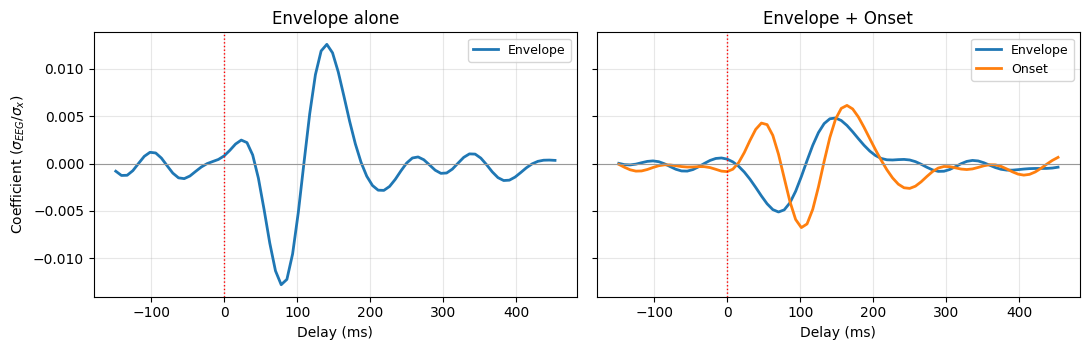

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)

for ax, (title, m, specs) in zip(axes, [
        ("Envelope alone", model, ["Envelope"]),
        ("Envelope + Onset", joint_model, ["Envelope", "Onset"])]):
    # `to_evoked` hands back the kernel as an mne.Evoked per feature: response
    # channels stay channels, the delays become the time axis (and may be
    # negative). It is also the bridge to the whole MNE plotting toolbox.
    evokeds = m.to_evoked()
    for spec in specs:
        ev = evokeds[spec]
        ax.plot(ev.times * 1e3, ev.data.mean(axis=0), lw=2, label=spec)
    ax.axvline(0, color="r", ls=":", lw=1)
    ax.axhline(0, color=".6", lw=.8)
    ax.set(xlabel="Delay (ms)", title=title)
    ax.legend(fontsize=9); ax.grid(alpha=.3)
axes[0].set_ylabel(r"Coefficient ($\sigma_{EEG}/\sigma_x$)")
plt.tight_layout();

## 14 · The joint cohort

The same 17 subjects, the same loading path, a different spec.

In [30]:
joint_group = TRFGroup(
    ["Envelope", "Onset"], default_window=WINDOW,
    cv="pooled", solver="ridge",
    delay_margin=DELAY_MARGIN,
    regularization_grid=GRID, metric="Pearson",
    diagnostics=True, criteria=True,
)
print("spec:", joint_group.features)

spec: ['Envelope', 'Onset']


In [31]:
for sub in SUBJECTS:
    sid = f"sub{sub:02d}"
    subject_data = build_subject(sub)
    joint_group.fit_subject(subject_data, sid)

    r = np.asarray(joint_group.results(sid)["metric"]).reshape(-1)
    print(f"  {sid}  λ {joint_group.results(sid)['regularization']:<9.4g}  "
          f"r mean {r.mean():.4f}  max {r.max():.4f}")

    del subject_data

joint_summary = joint_group.summary()
print(f"\nfitted {len(joint_group)} subjects")
print(f"GVIF across the cohort: "
      + " | ".join(f"{s} median {d['median']:.3f}"
                   for s, d in joint_summary["diagnostics"]["gvif"].items()))

  sub01  alpha 0.1585     r mean 0.0180  max 0.0279


  sub02  alpha 6.31       r mean 0.0128  max 0.0243


  sub04  alpha 1          r mean 0.0711  max 0.0972


  sub05  alpha 0.3981     r mean 0.0230  max 0.0354


  sub06  alpha 1e-08      r mean 0.0222  max 0.0362


...

  sub15  alpha 0.3981     r mean 0.0337  max 0.0627


  sub16  alpha 0.1585     r mean 0.0474  max 0.0721


  sub17  alpha 2.512      r mean 0.0088  max 0.0134


  sub18  alpha 0.0631     r mean 0.0557  max 0.0827


  sub19  alpha 0.1585     r mean 0.0372  max 0.0595

fitted 17 subjects
GVIF across the cohort: Envelope median 2.013 | Onset median 2.013


In [32]:
for spec in ["Envelope", "Onset"]:
    t_obs, pvals = joint_group.tfce(spec, n_permutations=N_PERMUTATIONS,
                                    seed=SEED, n_jobs=-1)
    sig = pvals < 0.05
    print(f"{spec:9s}: {sig.sum():,} of {sig.size:,} points p < .05 "
          f"({100 * sig.mean():.1f} %) | min p = {pvals.min():.4g}")

Envelope : 1,720 of 9,984 points p < .05 (17.2 %) | min p = 0.003906


Onset    : 1,596 of 9,984 points p < .05 (16.0 %) | min p = 0.001953


**`plot_features`** with two blocks is the figure the single-feature version could not
draw: one column per predictor, side by side, each with its own significance mask and its
own peak topography.

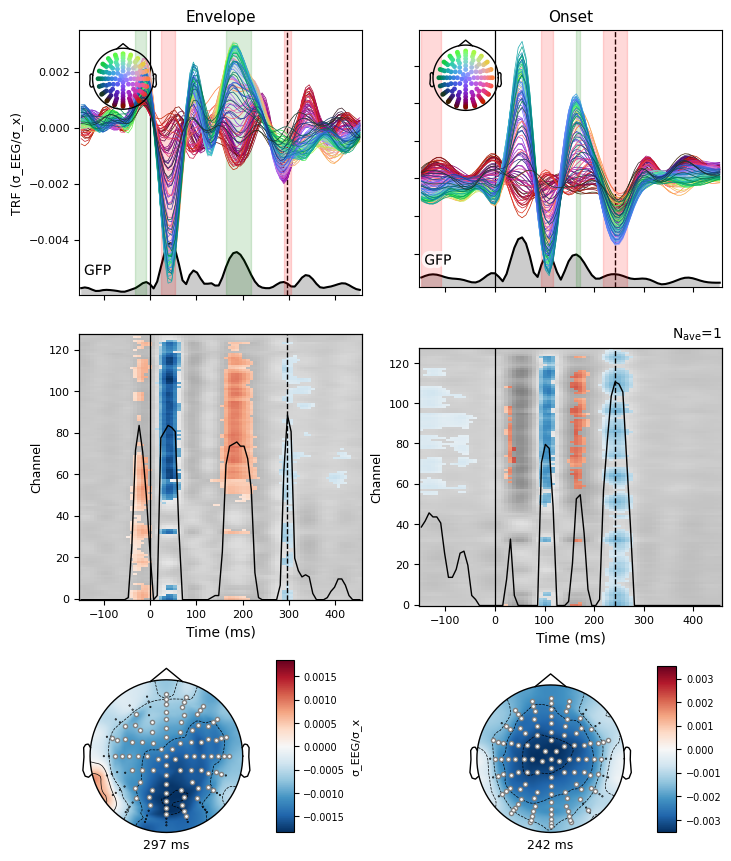

In [33]:
joint_group.plot_features(show_stats=True, min_sig_channels=0.3, show=True);

## 15 · Does the onset predictor earn its place?

TFCE asks whether a *kernel* differs from zero. A different question is which **model
spec** describes the cohort better — and no held-out metric can answer it, because adding
a feature block almost never makes the fit worse.

**`compare_to`** ranks the two cohorts by AIC and BIC, which price the extra complexity,
and reports the comparison two ways rather than choosing one quietly:

- **random effects** (`median`, `n_favouring_self`, `wilcoxon`) — each subject is one
  observation, so an unusual subject shows up in the vector instead of dominating;
- **fixed effects** (`total`) — the cohort as one large model, dominated by whoever
  contributed the most data.

**When the two disagree, that is the finding**, not something to resolve by picking the
convenient one.

Two sign conventions to keep straight: the difference is `self − other` and **lower is
better** for both criteria, so a **positive** delta favours `other`. That is the opposite
of `permutation_test_contrast`, where a positive `t_obs` favours `self`.

In [34]:
table = envelope_group.compare_to(joint_group)

print("self  = envelope_group (Envelope only)")
print("other = joint_group    (Envelope + Onset)\n")
for crit in ("aic", "bic"):
    print(f"{crit.upper():4s} best: {table.best[crit]:6s} | "
          f"subjects favouring self: {table.n_favouring_self[crit]:2d}/{len(joint_group)} | "
          f"median delta: {table.median[crit]:+.1f} | "
          f"Wilcoxon: stat {table.wilcoxon[crit][0]:.1f}, "
          f"p {table.wilcoxon[crit][1]:.4g}")
    print(f"      fixed-effects total: {table.total[crit]:+.1f}")

if table.best["aic"] != table.best["bic"]:
    print("\nAIC and BIC disagree. That is a result, not a problem to resolve: the "
          "onset block\nbuys enough fit to be worth it under AIC's price and not "
          "under BIC's steeper one.")
else:
    print(f"\nAIC and BIC agree on '{table.best['bic']}'.")

self  = envelope_group (Envelope only)
other = joint_group    (Envelope + Onset)

AIC  best: other  | subjects favouring self:  2/17 | median delta: +14409.3 | Wilcoxon: stat 7.0, p 0.0002899
      fixed-effects total: +347240.0
BIC  best: self   | subjects favouring self: 15/17 | median delta: -45983.9 | Wilcoxon: stat 20.0, p 0.005569
      fixed-effects total: -847015.8

AIC and BIC disagree. That is a result, not a problem to resolve: the onset block
buys enough fit to be worth it under AIC's price and not under BIC's steeper one.


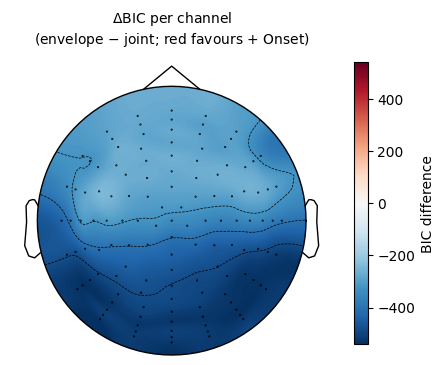

In [35]:
delta_bic = np.asarray(table.delta_bic_per_channel)
picks = mne.pick_channels(joint_group.info["ch_names"],
                          joint_group.common_channels, ordered=True)
info = mne.pick_info(joint_group.info, picks)

fig, ax = plt.subplots(figsize=(4.6, 4.2))
lim = np.abs(delta_bic).max()
im, _ = mne.viz.plot_topomap(delta_bic, info, axes=ax, show=False,
                             cmap="RdBu_r", vlim=(-lim, lim), contours=4)
ax.set_title(r"$\Delta$BIC per channel" "\n"
             "(envelope $-$ joint; red favours + Onset)", fontsize=10)
fig.colorbar(im, ax=ax, shrink=.75, label="BIC difference")
plt.tight_layout();

## 16 · Persisting a fitted cohort

A fitted cohort is a result, and results should outlive the session that produced them.
`save` writes the whole object — kernels, metrics, λ, diagnostics, cached statistics — and
`trflearn.load` restores one with the same API, so every figure above can be redrawn
without touching the 4 GB of source data again.

In [36]:
import trflearn

store = Path("natural_speech_envelope_cohort.pkl")
envelope_group.save(str(store))
reloaded = trflearn.load(str(store))

a = np.asarray(envelope_group.results(best)["coef_"]["Envelope"])
b = np.asarray(reloaded.results(best)["coef_"]["Envelope"])

print(f"saved            : {store.name} ({store.stat().st_size / 1e6:.2f} MB)")
print(f"reloaded cohort  : {len(reloaded)} subjects, features {reloaded.features}")
print(f"kernels identical: {np.allclose(a, b)}")
print(f"stats preserved  : {sorted(reloaded.stats_.keys())}")

saved            : natural_speech_envelope_cohort.pkl (18.34 MB)
reloaded cohort  : 17 subjects, features ['Envelope']
kernels identical: True
stats preserved  : ['Envelope']


That file stays on disk after the notebook finishes. The cell below removes it — it is
**commented out on purpose**, so running the notebook end to end never deletes anything
silently. Uncomment it if you would rather not leave an 18 MB artefact behind; the cell
above regenerates it.

In [37]:
# store.unlink(missing_ok=True)
# print(f"removed {store.name}")

## 17 · Summary

```
.fif (broadband, ICA-cleaned, mastoid-referenced)
   -> linear-phase FIR 1.5-14 Hz, zero-phase
   -> mne.Raw + Envelope / Onset predictors
   -> TRFData(y=[Raw, ...])  ->  create_partitions(5 folds, block-stratified)
        |
        |-- Part I   TRFGroup(["Envelope"])            -> the classic P1/N1/P2 kernel
        |-- Part II  TRFGroup(["Envelope", "Onset"])   -> joint estimation + GVIF
        |
   -> grand average -> TFCE over delays x channels -> AIC/BIC comparison
```

**What was demonstrated.** A container of named candidate features from which each model
selects its own subset; `mne.Raw` ingestion carrying the montage all the way through to the
group statistics; `delay_margin` fitting wide and trimming the edge artefact away; four λ
selection rules compared on one subject, including a smoothness-preferring one; design
diagnostics before and after a second block exists to compare against; the complete
plotting API at model, cohort and single-subject level; bootstrap distributions per
subject; TFCE with a real sensor adjacency; AIC/BIC model comparison under both
random- and fixed-effects readings; and a `save`/`load` round trip.

**What was not established.** Held-out correlations of a few hundredths are normal for
single-trial continuous speech, but they are small. Nothing here says the envelope is the
*right* representation of speech — only that it predicts above chance. Section 15 ranks two
specifications against each other; it does not suggest the winner is correct. And every
result inherits the upstream choices described in section 1, including a band-pass that
shapes the width of every kernel plotted above.